In [1]:
import pandas as pd
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt
import statsmodels.api as sm

plt.rcParams.update({'font.size': 14})


/opt/anaconda3/envs/impact-env/lib/python3.10/site-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_71037/855209635.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df['log_obs'] = np.log(region_df['dengue_inc'])
/var/folders/d6/h_rjrby126j22zqc7qm6wdp00000gn/T/ipykernel_71037/855209635.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  region_df[

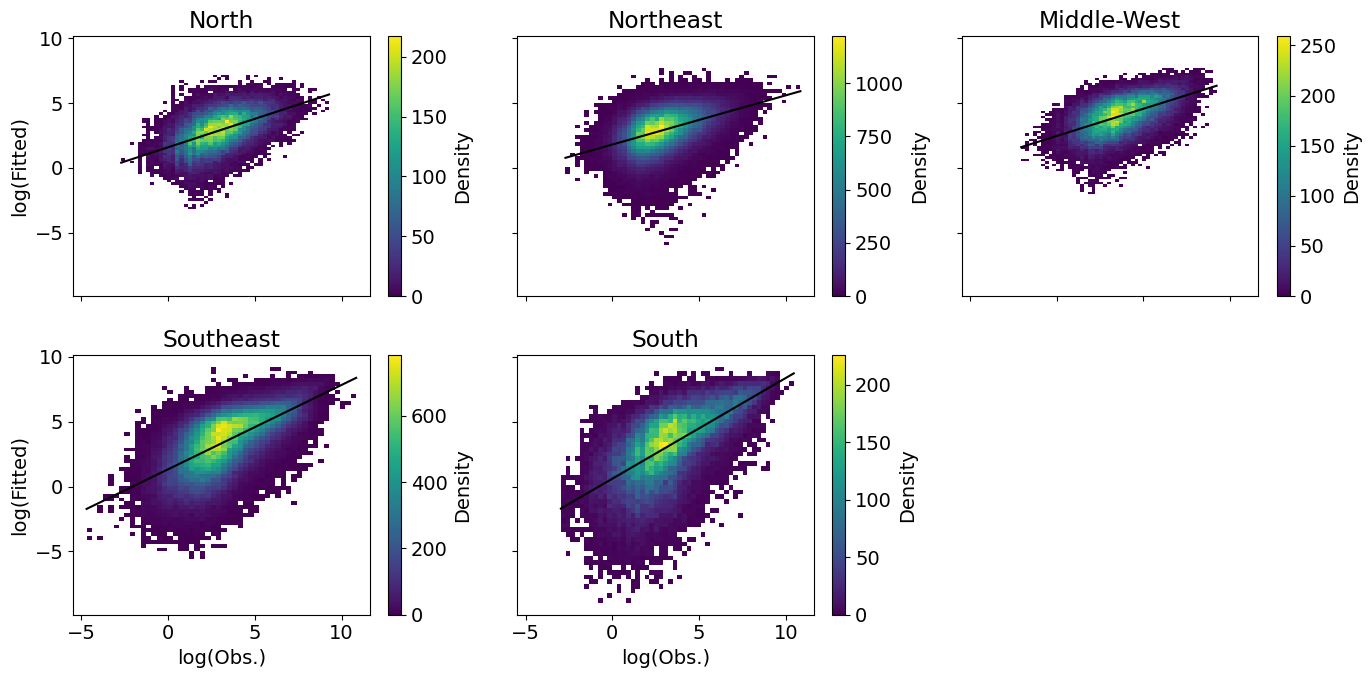

In [ ]:
df = pd.read_csv('data/dengue_with_fitted_values.csv', parse_dates=['date_first_symptoms'])

fig, axarr = plt.subplots(2, 3, figsize=(14, 7), sharex=True, sharey=True)

for ax, region in zip(axarr.flatten(), ['North', 'Northeast', 'Middle-West', 'Southeast', 'South']):
    region_df = df[df['region'] == region]

    region_df['log_obs'] = np.log(region_df['dengue_inc'])
    region_df['log_pred'] = np.log(region_df['pred_incidence'])

    region_df = region_df.dropna(subset=['log_obs', 'log_pred'])
    region_df = region_df[(region_df['dengue_inc'] > 0)]

    reg = sm.OLS(region_df['log_pred'], sm.add_constant(region_df['log_obs'])).fit()

    region_df['fitted_line'] = reg.fittedvalues

    sns.histplot(region_df, x='log_obs', y='log_pred', ax=ax, cbar=True, bins=50, cmap='viridis', cbar_kws={'label': 'Density'})
    region_df.sort_values('log_obs').plot(x='log_obs', y='fitted_line', ax=ax, color='k', legend=False)
    ax.set_title(region)
    ax.set_ylabel('log(Fitted)')
    ax.set_xlabel('log(Obs.)')

fig.delaxes(axarr[-1, -1])

plt.tight_layout()